In [ ]:
import jax.numpy as jnp
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math

import sys
from absl import flags
from ml_collections.config_flags import config_flags

import tensorflow as tf
tf.config.experimental.set_visible_devices([], "GPU") # Отключение GPU для TensorFlow

import os
import jax
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.8'

from td_sa_stack import get_dataset, TrainerModule, RegressionInceptionNetV1

%load_ext autoreload
%autoreload 2

In [ ]:
sys.argv = [
    "",
    "--config=td_sa_stack/config.py",
]

config_flags.DEFINE_config_file("config", None, "Training configuration.", lock_config=True)
# flags.DEFINE_string("workdir", None, "Work directory.")
# flags.DEFINE_enum("mode", None, ["train", "eval", "fid_stats"], "Running mode: train, eval or fid_stats")
# flags.DEFINE_string("eval_folder", "eval", "The folder name for storing evaluation results")


FLAGS = flags.FLAGS
FLAGS(sys.argv)

config = FLAGS.config

2025-06-14 10:55:46.155616: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749898546.183721   11469 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749898546.191718   11469 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749898546.210653   11469 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749898546.210681   11469 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749898546.210684   11469 computation_placer.cc:177] computation placer alr


Итоговый JAX массив картинок: (5, 32, 32, 3)


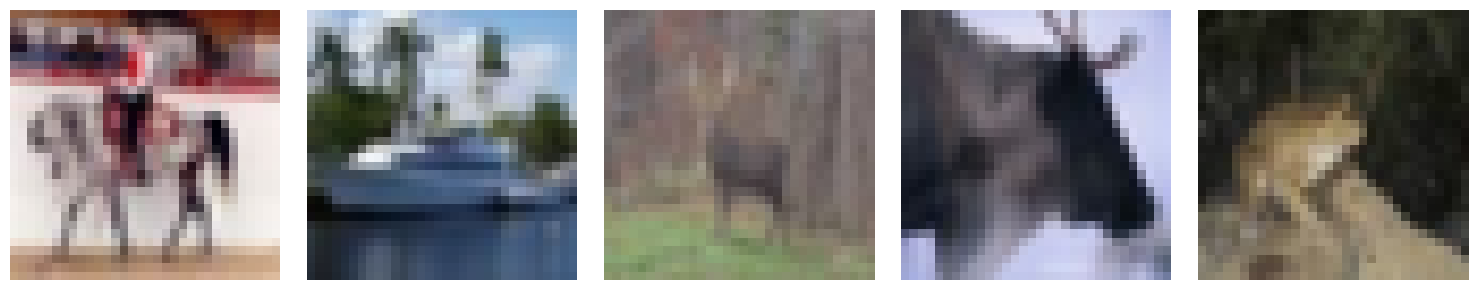


Тип данных: uint8
Диапазон значений: [0, 249]
Форма одной картинки: (32, 32, 3)
После нормализации: [0.000, 0.976]


In [1]:
dataset = tfds.load('cifar10', split='train', as_supervised=True, shuffle_files=False)

images = []
for i, (image, _) in enumerate(dataset.take(5)):
    image_numpy = image.numpy()
    image_jax = jnp.array(image_numpy)
    images.append(image_jax)

images_array = jnp.stack(images)

print(f"\nИтоговый JAX массив картинок: {images_array.shape}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    image_to_show = np.array(images[i])
    axes[i].imshow(image_to_show)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"\nТип данных: {images_array.dtype}")
print(f"Диапазон значений: [{images_array.min()}, {images_array.max()}]")
print(f"Форма одной картинки: {images_array[0].shape}")

images_normalized = images_array / 255.0
print(f"После нормализации: [{images_normalized.min():.3f}, {images_normalized.max():.3f}]") 

In [ ]:
train_ds, _, _ = get_dataset(config)

trainer = TrainerModule(config=config,
                        model_class=RegressionInceptionNetV1,
                        version=2)

In [ ]:
def get_trajectory(image: jnp.ndarray):
	min_num_steps, max_num_steps = config.data.min_num_steps, config.data.max_num_steps
	reward, gamma = config.data.reward, config.data.gamma

	num_steps = jax.random.randint((), minval=min_num_steps, maxval=max_num_steps)
	z = jax.random.normal(image.shape, dtype=image.dtype)

	ts = math.sqrt(2) * jnp.arange(num_steps, dtype=jnp.float32) % 1.0 # Имитация равномерного распределения
	ts = jnp.sort(ts, direction='ASCENDING') 
	ts = jnp.reshape(ts, (num_steps, 1, 1, 1))

	trajectory = z * (1 - ts) + image * ts # [None, 32, 32, 3] * [num_steps, None, None, None]

	s = trajectory[:-1]                # [num_steps-1, 32, 32, 3]
	s_next = trajectory[1:]            # [num_steps-1, 32, 32, 3]
	a = s_next - s                     # [num_steps-1, 32, 32, 3]
	a_next = image[None, ...] - s_next # [num_steps-1, 32, 32, 3]

	rewards = reward * (gamma ** jnp.arange(num_steps-1, 0, -1, dtype=jnp.float32)) # [num_steps-1]
	rewards = jnp.reshape(rewards, (-1, 1))

	transitions = jnp.concat([s, a, s_next, a_next], axis=-1) # [num_steps-1, 32, 32, 3*4=12]
	return transitions, rewards

In [ ]:
trajectories = []
for image in images:
    transitions, rewards = get_trajectory(image)
    trajectories.append((transitions, rewards))

transitions = jnp.concatenate([transition for transition, _ in trajectories])
rewards = jnp.concatenate([reward for _, reward in trajectories])

In [ ]:
q_vals = trainer.model.apply({"params": trainer.state.params, "batch_stats": trainer.state.batch_stats},
                        (transitions, rewards),
                        train=False,
                        train_rng=None,
                        mutable=False)